# Subset resampling and cross-validation

This example deepens the basic meta-optimiser walkthrough by focusing on two practical
questions:

  - how stable are the out-of-sample predictions produced by a plain optimiser versus a
    meta-optimiser when we evaluate them with cross validation?
  - what does the efficient frontier look like when the optimiser is a meta-optimiser that
    resamples the universe before averaging the result?

We use `MeanRisk` as the benchmark and `SubsetResampling` as the meta-
optimiser. The example also reuses the same clustering/prior setup as the standard meta-
optimiser page so the allocations can be compared directly.

> **When to reach for this**
>
> Reach for subset resampling, and meta-optimisers generally, when a single full-universe
> fit feels brittle — when small changes in the estimation window swing the allocation, or
> when you want a portfolio averaged over many resampled universes rather than committed to
> one point estimate. Cross-validation here is the tool for *checking* that stability, not
> for producing the final portfolio.

In [1]:
using PortfolioOptimisers, PrettyTables, StableRNGs

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. ReturnsResult data and shared ingredients

We use the same S&P 500 slice as the other optimiser examples. The shared prior and
clustering are computed once and reused everywhere below.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel, Statistics

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))]

pr = prior(EmpiricalPrior(), rd)
clr = clusterise(ClustersEstimator(; alg = DBHT()), pr.X)
jopti = JuMPOptimiser(; pe = pr, slv = slv)
jopto = JuMPOptimiser(; slv = slv)

JuMPOptimiser
       pe ┼ EmpiricalPrior
          │        ce ┼ PortfolioOptimisersCovariance
          │           │   ce ┼ Covariance
          │           │      │    me ┼ SimpleExpectedReturns
          │           │      │       │   w ┴ nothing
          │           │      │    ce ┼ GeneralCovariance
          │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
          │           │      │       │    w ┴ nothing
          │           │      │   alg ┴ FullMoment()
          │           │   mp ┼ MatrixProcessing
          │           │      │     pdm ┼ Posdef
          │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
          │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
          │           │      │      dn ┼ nothing
          │           │      │      dt ┼ nothing
          │           │      │     alg ┼ nothing
          │           │      │   order ┴ NTuple{4, Symbol}: (:pdm, :dn, :dt, :alg)

## 2. Reference allocations

We compute the plain minimum-variance portfolio and the three standard meta-optimisers.
These are the same building blocks as the shorter overview example, but here we will reuse
them for cross-validation and frontier comparisons.

In [3]:
res_bench = optimise(MeanRisk(; opt = JuMPOptimiser(; pe = pr, slv = slv)))

res_nco = optimise(NestedClustered(; pe = pr, cle = clr,
                                   opti = MeanRisk(; obj = MinimumRisk(), opt = jopti),
                                   opto = MeanRisk(; obj = MinimumRisk(), opt = jopto)), rd)

res_stk = optimise(Stacking(; pe = pr,
                            opti = [MeanRisk(; opt = jopti),
                                    HierarchicalRiskParity(;
                                                           opt = HierarchicalOptimiser(;
                                                                                       pe = pr)),
                                    InverseVolatility(; pe = pr)],
                            opto = MeanRisk(; obj = MinimumRisk(), opt = jopto)), rd)

res_ssr = optimise(SubsetResampling(; pe = pr,
                                    opt = MeanRisk(; obj = MinimumRisk(),
                                                   opt = JuMPOptimiser(; slv = slv)),
                                    subset_size = 0.7, n_subsets = 10, rng = StableRNG(123),
                                    seed = 42), rd)

pretty_table(DataFrame(; :assets => rd.nx, :MinVar => res_bench.w, :NCO => res_nco.w,
                       :Stacking => res_stk.w, :SubsetResampling => res_ssr.w);
             formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬──────────────────┐
│ assets │   MinVar │      NCO │ Stacking │ SubsetResampling │
│ String │  Float64 │  Float64 │  Float64 │          Float64 │
├────────┼──────────┼──────────┼──────────┼──────────────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    AMD │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    BBY │    0.0 % │    0.0 % │    0.0 % │            0.0 % │
│    CVX │  7.432 % │ 10.376 % │  7.432 % │          6.786 % │
│     GE │  0.806 % │    0.0 % │  0.806 % │          0.856 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │          0.677 % │
│    JNJ │ 36.974 % │ 31.364 % │ 36.974 % │         20.456 % │
│    JPM │  0.749 % │    0.0 % │  0.749 % │          1.915 % │
│     KO │ 11.161 % │ 10.028 % │ 11.161 % │          13.75 % │
│    LLY │    0.0 % │    0.0 % │    0.0 % │          0.735 % │
│    MRK │ 17.467 % │ 15.876 % │ 17.467 % │         19.

The meta-optimisers spread capital more than the plain fit, and SubsetResampling usually
smooths it the most because it averages over many smaller universes.

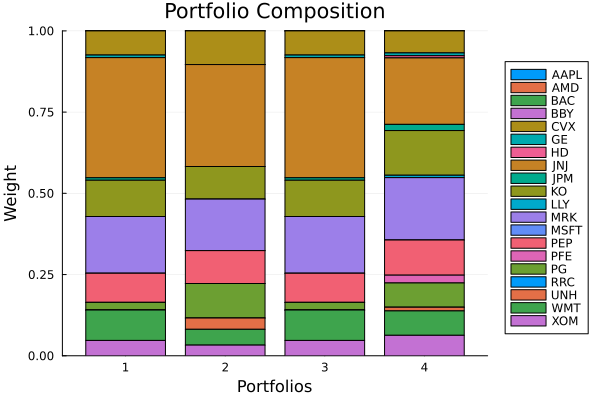

In [4]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_bench, res_nco, res_stk, res_ssr], rd)

## 3. Cross-validation prediction

We now evaluate the benchmark and the bagged optimiser with explicit cross-validation. The
`cross_val_predict` helper works on estimators, so we can compare the out-of-sample
prediction streams directly.

Note that the optimisers we hand it carry **no precomputed prior** — their `JuMPOptimiser` has
only a solver, so the prior is an estimator (the default `EmpiricalPrior`) refit on each
training fold. This is mandatory: a precomputed prior would have been fit on the whole sample,
leaking the test fold into training, so cross-validation **disallows** the precomputed form and
requires the estimator. (See the precomputed-vs-estimator note in the
[`MeanRisk` objectives](01_MeanRisk_Objectives.md) example.)

MeanRisk cross-val variance = 9.624610341649477e-5
SubsetResampling cross-val variance = 9.758428307687625e-5


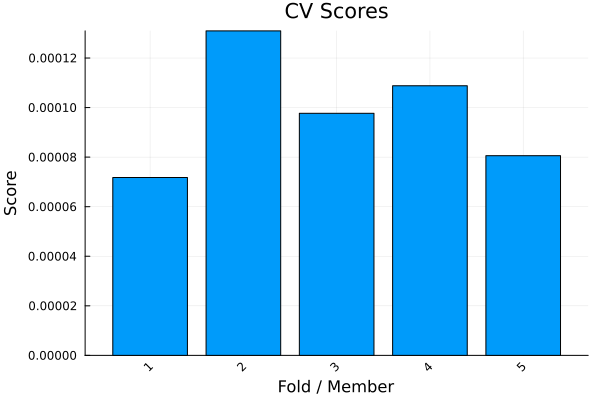

In [5]:
kfold = KFold(; n = 5)
cv_bench = cross_val_predict(MeanRisk(; opt = JuMPOptimiser(; slv = slv)), rd, kfold)
cv_ssr = cross_val_predict(SubsetResampling(;
                                            opt = MeanRisk(;
                                                           opt = JuMPOptimiser(; slv = slv)),
                                            subset_size = 0.7, n_subsets = 8,
                                            rng = StableRNG(123), seed = 42), rd, kfold)

scorer = NearestQuantilePrediction(; r = LowOrderMoment(; alg = SecondMoment()))
pp_bench = PopulationPredictionResult(; pred = [cv_bench])
pp_ssr = PopulationPredictionResult(; pred = [cv_ssr])
median_bench = scorer(pp_bench)
median_ssr = scorer(pp_ssr)

println("MeanRisk cross-val variance = $(expected_risk(LowOrderMoment(; alg = SecondMoment()), cv_bench))")
println("SubsetResampling cross-val variance = $(expected_risk(LowOrderMoment(; alg = SecondMoment()), cv_ssr))")

plot_cv_scores(LowOrderMoment(; alg = SecondMoment()), cv_bench)
plot_cv_scores(LowOrderMoment(; alg = SecondMoment()), cv_ssr)

The scorer returns the prediction closest to the median of the population. On both
optimisers that gives us a representative fold without hand-picking one ourselves.

In [6]:
println("Median benchmark fold id = $(median_bench.id)")
println("Median SSR fold id = $(median_ssr.id)")

Median benchmark fold id = nothing
Median SSR fold id = nothing


## 4. Efficient frontier of a meta-optimiser

The frontier example from the optimiser overview used a single `MeanRisk` problem. Here we
apply the same frontier sweep to the bagged optimiser, which gives us a frontier of
bagged portfolios rather than a frontier from a single full-universe fit.

┌───────┬────────────────┬────────────────────────┐
│ point │ MeanRisk_max_w │ SubsetResampling_max_w │
│ Int64 │        Float64 │                Float64 │
├───────┼────────────────┼────────────────────────┤
│     1 │       36.945 % │               20.935 % │
│     2 │       33.081 % │               19.728 % │
│     3 │       29.033 % │               22.669 % │
│     4 │       35.457 % │               25.797 % │
│     5 │       41.881 % │                28.98 % │
│     6 │       48.465 % │               32.193 % │
│     7 │       55.101 % │               35.481 % │
│     8 │       60.789 % │               38.633 % │
│     9 │        65.84 % │               41.537 % │
│    10 │       68.803 % │               39.684 % │
│    11 │       55.042 % │               40.671 % │
│    12 │       58.718 % │               49.126 % │
│    13 │       72.479 % │               57.751 % │
│    14 │       86.239 % │               66.375 % │
│    15 │        100.0 % │                 75.0 % │
└───────┴───

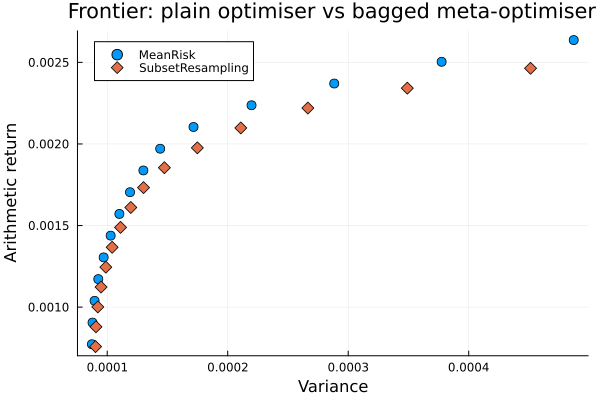

In [7]:
frontier_ret = ArithmeticReturn(; lb = Frontier(; N = 15))
mr_front = MeanRisk(; opt = JuMPOptimiser(; pe = pr, slv = slv, ret = frontier_ret))
ssr_front = SubsetResampling(; pe = pr,
                             opt = MeanRisk(;
                                            opt = JuMPOptimiser(; slv = slv,
                                                                ret = frontier_ret)),
                             subset_size = 0.7, n_subsets = 8, rng = StableRNG(123),
                             seed = 42)

res_mf = optimise(mr_front)
res_sf = optimise(ssr_front, rd)

rf = factory(Variance(), pr)
xs_m = [expected_risk(rf, w, pr.X) for w in res_mf.w]
ys_m = [expected_return(ArithmeticReturn(), w, pr) for w in res_mf.w]
xs_s = [expected_risk(rf, w, pr.X) for w in res_sf.w]
ys_s = [expected_return(ArithmeticReturn(), w, pr) for w in res_sf.w]

pretty_table(DataFrame(; :point => 1:length(res_mf.w),
                       :MeanRisk_max_w => [maximum(w) for w in res_mf.w],
                       :SubsetResampling_max_w => [maximum(w) for w in res_sf.w]);
             formatters = [resfmt])

plot(xs_m, ys_m; seriestype = :scatter, marker = (:circle, 5), label = "MeanRisk",
     xlabel = "Variance", ylabel = "Arithmetic return",
     title = "Frontier: plain optimiser vs bagged meta-optimiser")
plot!(xs_s, ys_s; seriestype = :scatter, marker = (:diamond, 6), label = "SubsetResampling")

## Summary

Meta-optimisers help when a single fit feels too brittle.

  - `cross_val_predict` shows how the benchmark and the bagged optimiser behave
    under repeated out-of-sample evaluation.
  - `SubsetResampling` smooths allocations by averaging many subset solves.
  - Frontier sweeps still work on the meta-optimiser, so you can compare its trade-off
    curve against the plain optimiser instead of choosing only one portfolio.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*